# Model v6 — East African Prices + Feature Engineering

## What we're doing

v4 reached MAE 223 with global (Chicago CME) maize price + annual FX, trained on 155 rows.
The global price had only 6.5% importance — Uganda trades in East African markets, not CME.

**5 improvements over v4:**
1. **East African regional maize price** — Kenya (Nairobi) + Tanzania (Dar es Salaam) from WFP/HDX, averaged to USD/kg. Global price used as fallback where EA data is missing (post-2022).
2. **price_lag_6 and price_lag_12** — capture seasonality (harvest cycles repeat at 6 and 12 month intervals)
3. **price_momentum** = price_lag_1 - price_lag_2 — direction of recent price movement
4. **Cyclical month encoding** — sin(2π×month/12) and cos(2π×month/12) instead of raw month number. Raw month treats Jan=1 and Dec=12 as far apart; cyclical treats them as neighbours.
5. **Annual FX kept** — monthly FX source not found; World Bank annual FX remains

## 1. Load Uganda WFP Maize Prices

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from huggingface_hub import hf_hub_download

prices_path = hf_hub_download(
    repo_id="byabasaija/uganda-maize-prices",
    filename="uganda_maize_prices_owino.csv",
    repo_type="dataset",
)
prices_df = pd.read_csv(prices_path)
prices_df["date"] = pd.to_datetime(prices_df[["year", "month"]].assign(day=1))
prices_df = prices_df.sort_values("date").reset_index(drop=True)

print(f"WFP Uganda prices: {prices_df['date'].min().date()} to {prices_df['date'].max().date()}")
print(f"Rows: {len(prices_df)}")
prices_df[["date", "year", "month", "price"]].head()

WFP Uganda prices: 2010-01-01 to 2025-04-01
Rows: 177


,date,year,month,price
0,2010-01-01,2010,1,975.0
1,2010-02-01,2010,2,850.0
2,2010-03-01,2010,3,1000.0
3,2010-04-01,2010,4,825.0
4,2010-05-01,2010,5,800.0


## 2. Load East African Maize Prices

WFP market monitoring data for Kenya (Nairobi) and Tanzania (Dar es Salaam) from HDX.
Using USD price field to avoid cross-currency conversion.

**Coverage:**
- Kenya (Nairobi, Maize/KG): Jan 2006 – Mar 2022
- Tanzania (Dar es Salaam, Maize/100KG): Jan 2006 – Mar 2020

For months after Mar 2022: EA data unavailable — global maize price used as fallback.

In [2]:
import requests, io

# Kenya — Nairobi, Maize per KG
url_ke = "https://data.humdata.org/dataset/e0d3fba6-f9a2-45d7-b949-140c455197ff/resource/517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv"
df_ke = pd.read_csv(io.StringIO(requests.get(url_ke, timeout=60, verify=False).text))

ke_maize = df_ke[
    (df_ke["commodity"] == "Maize") &
    (df_ke["unit"] == "KG") &
    (df_ke["market"] == "Nairobi")
][["date", "usdprice"]].rename(columns={"usdprice": "ke_maize_usd"})
ke_maize["date"] = pd.to_datetime(ke_maize["date"]).dt.to_period("M").dt.to_timestamp()
ke_maize = ke_maize.sort_values("date").reset_index(drop=True)

# Tanzania — Dar es Salaam, Maize per 100KG (convert to per KG)
url_tz = "https://data.humdata.org/dataset/5090d858-a300-49fe-a953-4ec4e3526fc2/resource/2ff38c1a-a8f7-45b2-9209-090200c859da/download/wfp_food_prices_tza.csv"
df_tz = pd.read_csv(io.StringIO(requests.get(url_tz, timeout=60, verify=False).text))

tz_maize = df_tz[
    (df_tz["commodity"] == "Maize") &
    (df_tz["unit"] == "100 KG") &
    (df_tz["market"] == "Dar Es Salaam")
][["date", "usdprice"]].rename(columns={"usdprice": "tz_maize_usd"})
tz_maize["date"] = pd.to_datetime(tz_maize["date"]).dt.to_period("M").dt.to_timestamp()
tz_maize["tz_maize_usd"] = tz_maize["tz_maize_usd"] / 100  # per-KG
tz_maize = tz_maize.sort_values("date").reset_index(drop=True)

# Merge into EA average
ea_maize = ke_maize.merge(tz_maize, on="date", how="outer").sort_values("date").reset_index(drop=True)
ea_maize["ea_maize_usd"] = ea_maize[["ke_maize_usd", "tz_maize_usd"]].mean(axis=1)

print(f"Kenya:    {ke_maize['date'].min().date()} to {ke_maize['date'].max().date()} ({len(ke_maize)} rows)")
print(f"Tanzania: {tz_maize['date'].min().date()} to {tz_maize['date'].max().date()} ({len(tz_maize)} rows)")
print(f"EA combined: {len(ea_maize)} rows, {ea_maize.ea_maize_usd.isna().sum()} NaN")
ea_maize[["date", "ke_maize_usd", "tz_maize_usd", "ea_maize_usd"]].tail(8)

Kenya:    2006-01-01 to 2022-03-01 (190 rows)
Tanzania: 2006-01-01 to 2020-03-01 (169 rows)
EA combined: 191 rows, 0 NaN


,date,ke_maize_usd,tz_maize_usd,ea_maize_usd
183,2021-06-01,0.30,NaN,0.30
184,2021-07-01,0.31,NaN,0.31
185,2021-08-01,0.31,NaN,0.31
186,2021-09-01,0.31,NaN,0.31
187,2021-10-01,0.29,NaN,0.29
188,2021-11-01,0.29,NaN,0.29
189,2022-02-01,0.35,NaN,0.35
190,2022-03-01,0.22,NaN,0.22


## 3. Load Global Maize Price (World Bank Pink Sheet)

Used as fallback for months where EA data is unavailable (post-March 2022).
Price is in USD/tonne — we'll convert to USD/kg (÷1000) for consistent units.

In [3]:
resp = requests.get(
    "https://thedocs.worldbank.org/en/doc/5d903e848db1d1b83e0ec8f744e55570-0350012021/related/CMO-Historical-Data-Monthly.xlsx",
    timeout=60,
)
resp.raise_for_status()

raw = pd.read_excel(io.BytesIO(resp.content), sheet_name="Monthly Prices", header=4)
raw = raw.rename(columns={"Unnamed: 0": "date"})
raw = raw[raw["date"].notna() & raw["date"].astype(str).str.match(r"\d{4}M\d{2}")]
raw["date"] = pd.to_datetime(raw["date"].astype(str).str.replace("M", "-"), format="%Y-%m")

global_maize = raw[["date", "Maize"]].rename(columns={"Maize": "global_maize_usd_tonne"}).dropna().sort_values("date").reset_index(drop=True)
global_maize["global_maize_usd_kg"] = global_maize["global_maize_usd_tonne"] / 1000  # USD/kg

print(f"Global maize: {global_maize['date'].min().date()} to {global_maize['date'].max().date()} ({len(global_maize)} rows)")
global_maize[["date", "global_maize_usd_tonne", "global_maize_usd_kg"]].tail(6)

Global maize: 1960-01-01 to 2024-12-01 (780 rows)


,date,global_maize_usd_tonne,global_maize_usd_kg
774,2024-07-01,177.429214,0.177429
775,2024-08-01,170.324757,0.170325
776,2024-09-01,184.967154,0.184967
777,2024-10-01,190.335722,0.190336
778,2024-11-01,201.33106,0.201331
779,2024-12-01,202.59757,0.202598


## 4. Load FX Rate (World Bank, annual UGX/USD)

In [4]:
resp = requests.get(
    "https://api.worldbank.org/v2/country/UGA/indicator/PA.NUS.FCRF",
    params={"format": "json", "per_page": 100},
    timeout=30,
)
resp.raise_for_status()

records = [r for r in resp.json()[1] if r["value"] is not None]
fx_df = pd.DataFrame([
    {"year": int(r["date"]), "fx_ugx_usd": r["value"]}
    for r in records
]).sort_values("year").reset_index(drop=True)

print(f"FX data: {fx_df['year'].min()} to {fx_df['year'].max()} ({len(fx_df)} annual values)")
fx_df[fx_df["year"] >= 2010]

FX data: 1960 to 2024 (65 annual values)


,year,fx_ugx_usd
50,2010,2177.557507
51,2011,2522.802033
52,2012,2504.563078
53,2013,2586.889569
54,2014,2599.788201
55,2015,3240.645420
56,2016,3420.098007
57,2017,3611.224458
58,2018,3727.068995
59,2019,3704.049072


## 5. Merge All Data

Join strategy:
- Uganda prices → EA maize (outer join, then fill gaps with global fallback)
- EA maize → Global maize (for filling post-2022 gaps)
- FX by year (annual)

Final `regional_maize_usd` feature: EA price when available, global (USD/kg) when EA is missing.

In [5]:
# Uganda prices ← EA maize (by date)
merged = prices_df.merge(
    ea_maize[["date", "ea_maize_usd"]], on="date", how="left"
)

# Uganda prices ← Global maize (by date)
merged = merged.merge(
    global_maize[["date", "global_maize_usd_kg"]], on="date", how="left"
)

# Combined regional feature: EA where available, global as fallback
merged["regional_maize_usd"] = merged["ea_maize_usd"].fillna(merged["global_maize_usd_kg"])

# FX by year
merged = merged.merge(fx_df, on="year", how="inner")
merged = merged.sort_values("date").reset_index(drop=True)

# Check EA coverage
ea_rows = merged["ea_maize_usd"].notna().sum()
global_fallback = merged["ea_maize_usd"].isna().sum()
print(f"Total rows: {len(merged)}")
print(f"Rows using EA price:     {ea_rows} ({ea_rows/len(merged)*100:.0f}%)")
print(f"Rows using global price: {global_fallback} ({global_fallback/len(merged)*100:.0f}%) ← fallback")
print(f"regional_maize_usd NaN: {merged['regional_maize_usd'].isna().sum()}")
merged[["date", "price", "ea_maize_usd", "global_maize_usd_kg", "regional_maize_usd", "fx_ugx_usd"]].tail(8)

Total rows: 174
Rows using EA price:     136 (78%)
Rows using global price: 38 (22%) ← fallback
regional_maize_usd NaN: 0


,date,price,ea_maize_usd,global_maize_usd_kg,regional_maize_usd,fx_ugx_usd
166,2024-05-01,2000.0,NaN,0.197793,0.197793,3757.262535
167,2024-06-01,2000.0,NaN,0.192507,0.192507,3757.262535
168,2024-07-01,1700.0,NaN,0.177429,0.177429,3757.262535
169,2024-08-01,1872.0,NaN,0.170325,0.170325,3757.262535
170,2024-09-01,1912.5,NaN,0.184967,0.184967,3757.262535
171,2024-10-01,1837.5,NaN,0.190336,0.190336,3757.262535
172,2024-11-01,2000.0,NaN,0.201331,0.201331,3757.262535
173,2024-12-01,2000.0,NaN,0.202598,0.202598,3757.262535


## 6. Build Feature Matrix (v6 Improvements)

**New vs v4:**
| Feature | v4 | v6 |
|---------|----|----||
| price_lag_1/2/3 | ✓ | ✓ |
| price_lag_6 | ✗ | ✓ new |
| price_lag_12 | ✗ | ✓ new |
| rolling_mean_3/6 | ✓ | ✓ |
| price_momentum | ✗ | ✓ new |
| month (raw) | ✓ | ✗ replaced |
| sin_month + cos_month | ✗ | ✓ new |
| year | ✓ | ✓ |
| global_maize_usd | ✓ | ✗ replaced |
| regional_maize_usd | ✗ | ✓ new |
| fx_ugx_usd | ✓ | ✓ |

Starting from index 12 (need 12 months history for price_lag_12).

In [7]:
prices_series = merged["price"].tolist()
feature_rows = []
targets = []

for i in range(12, len(merged)):
    past = prices_series[i - 12: i]  # 12 months of history
    row = merged.iloc[i]

    month = int(row["month"])
    feats = {
        # Lag features
        "price_lag_1":   past[-1],
        "price_lag_2":   past[-2],
        "price_lag_3":   past[-3],
        "price_lag_6":   past[-6],
        "price_lag_12":  past[-12],
        # Rolling means
        "rolling_mean_3": float(np.mean(past[-3:])),
        "rolling_mean_6": float(np.mean(past[-6:])),
        # Momentum: direction of recent price movement
        "price_momentum": past[-1] - past[-2],
        # Cyclical month encoding
        "sin_month": np.sin(2 * np.pi * month / 12),
        "cos_month": np.cos(2 * np.pi * month / 12),
        # Time
        "year": int(row["year"]),
        # External
        "regional_maize_usd": row["regional_maize_usd"],
        "fx_ugx_usd": row["fx_ugx_usd"],
    }
    feature_rows.append(feats)
    targets.append(prices_series[i])

FEATURE_COLS = [
    "price_lag_1", "price_lag_2", "price_lag_3",
    "price_lag_6", "price_lag_12",
    "rolling_mean_3", "rolling_mean_6",
    "price_momentum",
    "sin_month", "cos_month",
    "year",
    "regional_maize_usd", "fx_ugx_usd",
]

X = pd.DataFrame(feature_rows)[FEATURE_COLS]
y = pd.Series(targets)
merged_trimmed = merged.iloc[12:].reset_index(drop=True)

print(f"Feature matrix: {X.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
X.head(3)

Feature matrix: (162, 13)
Features (13): ['price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_6', 'price_lag_12', 'rolling_mean_3', 'rolling_mean_6', 'price_momentum', 'sin_month', 'cos_month', 'year', 'regional_maize_usd', 'fx_ugx_usd']


,price_lag_1,price_lag_2,price_lag_3,price_lag_6,price_lag_12,rolling_mean_3,rolling_mean_6,price_momentum,sin_month,cos_month,year,regional_maize_usd,fx_ugx_usd
0,850.0,832.69,738.46,800.00,975.0,807.05,760.251667,17.31,0.500000,8.660254e-01,2011,0.22515,2522.802033
1,1150.0,850.00,832.69,658.18,850.0,944.23,818.585000,300.00,0.866025,5.000000e-01,2011,0.26015,2522.802033
2,850.0,1150.00,850.00,682.18,1000.0,950.00,850.555000,-300.00,1.000000,6.123234e-17,2011,0.26520,2522.802033


## 7. Train/Test Split

Same split as v3/v4: train on ≤2023, test on 2024+.

In [8]:
train_mask = merged_trimmed["year"] <= 2023
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows  ({merged_trimmed[train_mask]['date'].min().date()} to {merged_trimmed[train_mask]['date'].max().date()})")
print(f"Test:  {len(X_test)} rows  ({merged_trimmed[~train_mask]['date'].min().date()} to {merged_trimmed[~train_mask]['date'].max().date()})")
print()
print(f"v4 had 155 train rows — v6 has {len(X_train)} (fewer because lag_12 needs 12 months warmup)")

Train: 150 rows  (2011-01-01 to 2023-12-01)
Test:  12 rows  (2024-01-01 to 2024-12-01)

v4 had 155 train rows — v6 has 150 (fewer because lag_12 needs 12 months warmup)


## 8. Train and Evaluate

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.0f} UGX/kg")
print(f"R²  : {r2:.4f}")
print()
print("Model comparison (all in nominal UGX/kg):")
print(f"  Naive baseline (rolling mean 3) : 196 UGX/kg")
print(f"  v3 — maize CPI, 65 train rows   : 224 UGX/kg  (leaky — uses same-month CPI)")
print(f"  v3 — CPI lag-1 (honest)         : 268 UGX/kg")
print(f"  v4 — global maize + FX (no CPI) : 223 UGX/kg")
print(f"  v5 — real prices, no CPI        : 263 UGX/kg")
print(f"  v6 — EA prices + eng. features  : {mae:,.0f} UGX/kg  ← this model")

MAE : 216 UGX/kg
R²  : -1.1250

Model comparison (all in nominal UGX/kg):
  Naive baseline (rolling mean 3) : 196 UGX/kg
  v3 — maize CPI, 65 train rows   : 224 UGX/kg  (leaky — uses same-month CPI)
  v3 — CPI lag-1 (honest)         : 268 UGX/kg
  v4 — global maize + FX (no CPI) : 223 UGX/kg
  v5 — real prices, no CPI        : 263 UGX/kg
  v6 — EA prices + eng. features  : 216 UGX/kg  ← this model


## 9. Feature Importance

In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Feature importances:")
for name, score in importances.items():
    bar = "█" * int(score * 40)
    print(f"  {score:.4f}  {bar}  {name}")

Feature importances:
  0.3827  ███████████████  price_lag_1
  0.1906  ███████  rolling_mean_3
  0.1241  ████  year
  0.0689  ██  rolling_mean_6
  0.0502  ██  regional_maize_usd
  0.0356  █  price_lag_2
  0.0307  █  price_lag_3
  0.0291  █  fx_ugx_usd
  0.0218    price_lag_6
  0.0181    price_lag_12
  0.0167    sin_month
  0.0162    price_momentum
  0.0155    cos_month


## 10. Visualise Predictions vs Actual

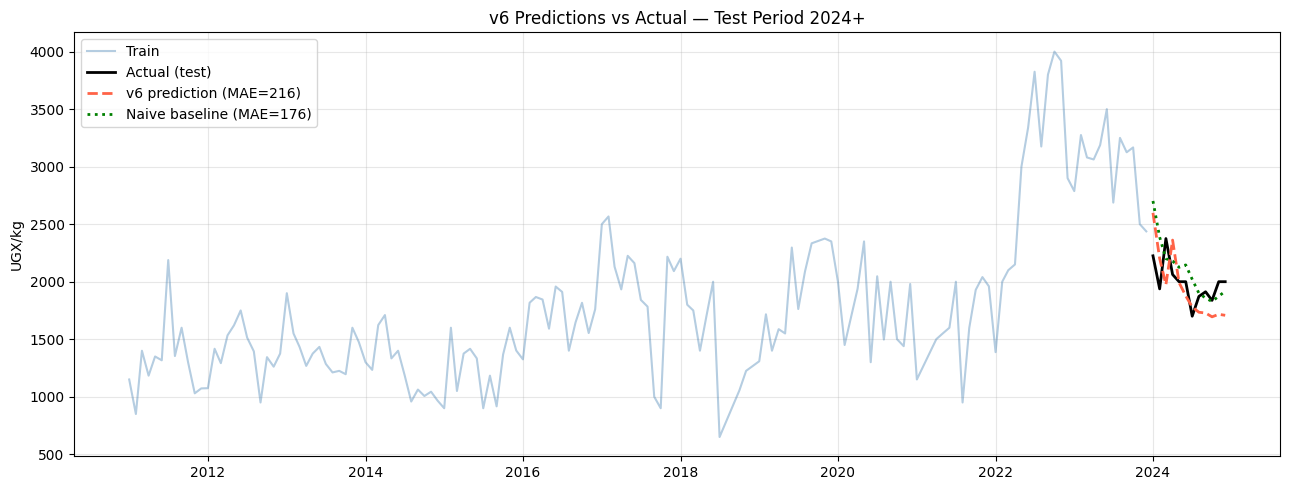

Saved → v6_predictions.png


In [11]:
import matplotlib.pyplot as plt

test_dates = merged_trimmed[~train_mask]["date"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(merged_trimmed[train_mask]["date"], y_train, color="steelblue", alpha=0.4, label="Train")
ax.plot(test_dates, y_test.values, color="black", linewidth=2, label="Actual (test)")
ax.plot(test_dates, y_pred, color="tomato", linewidth=2, linestyle="--", label=f"v6 prediction (MAE={mae:.0f})")

# Naive baseline for comparison
naive_pred = merged_trimmed[~train_mask].apply(
    lambda r: y[merged_trimmed["date"] < r["date"]].tail(3).mean(), axis=1
)
naive_mae = mean_absolute_error(y_test.values, naive_pred.values)
ax.plot(test_dates, naive_pred.values, color="green", linewidth=2, linestyle=":", label=f"Naive baseline (MAE={naive_mae:.0f})")

ax.set_title("v6 Predictions vs Actual — Test Period 2024+")
ax.set_ylabel("UGX/kg")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("v6_predictions.png", dpi=130)
plt.show()
print(f"Saved → v6_predictions.png")

## 11. Save Model

In [12]:
import joblib

joblib.dump(model, "maize_price_model_v6.pkl")
print("Saved → maize_price_model_v6.pkl")
print()
print("API changes needed to deploy v6:")
print("  - Fetch EA maize price (Kenya/Tanzania WFP) at predict time")
print("  - Fallback to global maize price when EA unavailable")
print("  - Compute price_lag_6, price_lag_12 — need 12 months of price history")
print("  - Compute sin_month, cos_month from request month")
print("  - Compute price_momentum from lag_1 - lag_2")

Saved → maize_price_model_v6.pkl

API changes needed to deploy v6:
  - Fetch EA maize price (Kenya/Tanzania WFP) at predict time
  - Fallback to global maize price when EA unavailable
  - Compute price_lag_6, price_lag_12 — need 12 months of price history
  - Compute sin_month, cos_month from request month
  - Compute price_momentum from lag_1 - lag_2
